### Run over 5 inital states, 10 rng seeds each

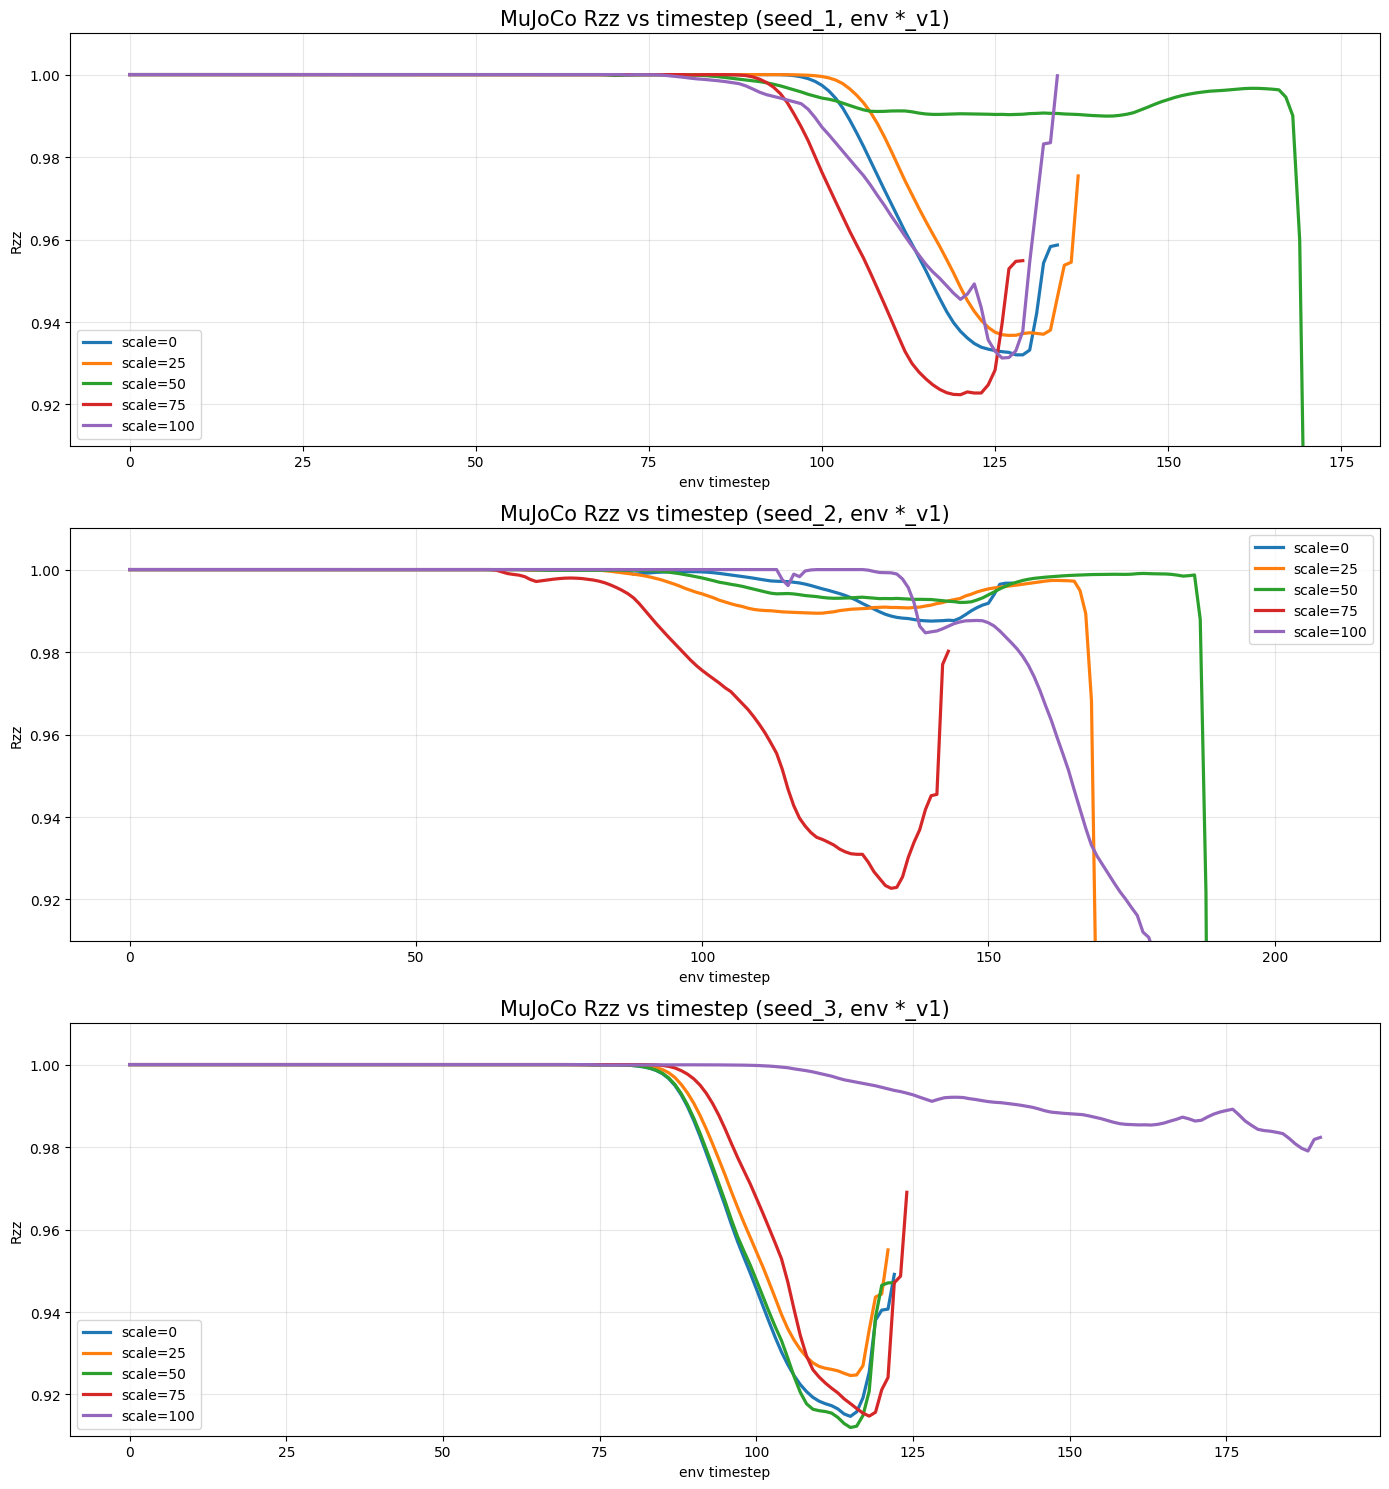

available seeds: [1, 2, 3]
missing seeds: []
seed 1: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 2: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 3: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101
Note: scale=10 is included only if dp_guidance_l10 exists in this run.


In [ ]:
# Comparison to single seed tests of diffusion_guidance.ipynb

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Config: same env used in guidance/diffusion_guidance.ipynb ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_SEEDS = [1, 2, 3]
TARGET_INIT_NAME = "n16h300r60g1bYfYv1"  # exact env init from diffusion_guidance.ipynb
TARGET_INIT_SUFFIX = "v1"

# Map method folder -> guidance scale label for plotting
METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,   # optional (not present in current comparison run)
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
}


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def _load_seed_series(run_root: Path, repo_root: Path, seed: int):
    series = []
    for method_slug, scale in sorted(METHOD_SCALE_MAP.items(), key=lambda kv: kv[1]):
        rows_path = run_root / method_slug / "rollout_rows.jsonl"
        rows = _read_rows(rows_path)
        if not rows:
            continue

        # Match seed + exact init first, then fallback to *_v1 suffix.
        candidates = [
            r for r in rows
            if int(r.get("seed", -1)) == seed
            and str(r.get("init_name", "")) == TARGET_INIT_NAME
        ]
        if not candidates:
            candidates = [
                r for r in rows
                if int(r.get("seed", -1)) == seed
                and str(r.get("init_name", "")).endswith(TARGET_INIT_SUFFIX)
            ]

        if not candidates:
            continue

        row = candidates[0]
        combo_dir = Path(row["combo_dir"])
        if not combo_dir.is_absolute():
            combo_dir = (repo_root / combo_dir).resolve()

        npz_path = combo_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        if "rzz_mujoco" not in data.files:
            continue

        rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
        series.append((scale, rzz, method_slug, row.get("init_name", "")))

    series.sort(key=lambda x: x[0])
    return series


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()
if not run_root.exists():
    raise FileNotFoundError(f"Run root not found: {run_root}")

seed_to_series = {}
for seed in TARGET_SEEDS:
    seed_to_series[seed] = _load_seed_series(run_root, repo_root, seed)

available_seeds = [s for s in TARGET_SEEDS if seed_to_series[s]]
missing_seeds = [s for s in TARGET_SEEDS if not seed_to_series[s]]
if not available_seeds:
    raise RuntimeError("No matching rollouts found for requested seed/env filter.")

# Use shared y-axis limits for easier cross-seed comparison.
all_rzz = np.concatenate([rzz for s in available_seeds for _, rzz, _, _ in seed_to_series[s]])
y_min = float(all_rzz.min()) - 0.002
y_max = float(all_rzz.max()) + 0.002

fig, axes = plt.subplots(
    nrows=len(available_seeds),
    ncols=1,
    figsize=(14, 5 * len(available_seeds)),
    sharey=True,
)
if len(available_seeds) == 1:
    axes = [axes]

for ax, seed in zip(axes, available_seeds):
    series = seed_to_series[seed]
    for scale, rzz, method_slug, init_name in series:
        ax.plot(np.arange(len(rzz)), rzz, linewidth=2.3, label=f"scale={scale}")

    ax.set_title(f"MuJoCo Rzz vs timestep (seed_{seed}, env *_v1)", fontsize=15)
    ax.set_xlabel("env timestep")
    ax.set_ylabel("Rzz")
    ax.set_ylim(0.91, 1.01)
    ax.grid(alpha=0.30)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("available seeds:", available_seeds)
print("missing seeds:", missing_seeds)
for seed in available_seeds:
    scales = [f"scale={s}" for s, *_ in seed_to_series[seed]]
    init_name = seed_to_series[seed][0][3]
    print(f"seed {seed}:", scales, "| init_name:", init_name)

print("run root:", run_root)
print("Note: scale=10 is included only if dp_guidance_l10 exists in this run.")

In [ ]:
# Result table per method and overall

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Reload config and helper functions ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_INIT_SUFFIX = "v1"

METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
    "snr_k8": "snr_k8",  # sample-and-rank
}

METHOD_LABELS = {
    "dp_base": "DP Base",
    "dp_guidance_l10": "DP Guidance (λ=10)",
    "dp_guidance_l25": "DP Guidance (λ=25)",
    "dp_guidance_l50": "DP Guidance (λ=50)",
    "dp_guidance_l75": "DP Guidance (λ=75)",
    "dp_guidance_l100": "DP Guidance (λ=100)",
    "snr_k8": "Sample-and-Rank (k=8)",
}

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()

# Aggregate mean Rzz per method, overall and per environment
method_to_rzz_values = defaultdict(list)
method_to_env_rzz = defaultdict(lambda: defaultdict(list))

for method_slug in METHOD_SCALE_MAP.keys():
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    rows = _read_rows(rows_path)
    
    for row in rows:
        init_name = str(row.get("init_name", ""))
        if not init_name.endswith(TARGET_INIT_SUFFIX):
            continue
        
        mean_rzz = float(row.get("mean_rzz", np.nan))
        if not np.isnan(mean_rzz):
            method_to_rzz_values[method_slug].append(mean_rzz)
            method_to_env_rzz[method_slug][init_name].append(mean_rzz)

# Compute overall averages per method
overall_results = []
for method_slug, rzz_list in sorted(method_to_rzz_values.items()):
    if not rzz_list:
        continue
    mean = np.mean(rzz_list)
    std = np.std(rzz_list)
    count = len(rzz_list)
    label = METHOD_LABELS.get(method_slug, method_slug)
    overall_results.append({
        "slug": method_slug,
        "label": label,
        "mean": mean,
        "std": std,
        "count": count,
    })

# Sort by mean descending (best first)
overall_results.sort(key=lambda x: x["mean"], reverse=True)

print("=" * 90)
print("OVERALL MEAN RZZ ACROSS ALL SEEDS & ENVIRONMENTS")
print("=" * 90)
print(f"{'Method':<35} {'Mean Rzz':>12} {'Std Dev':>12} {'N':>6}")
print("-" * 90)
for r in overall_results:
    print(f"{r['label']:<35} {r['mean']:>12.6f} {r['std']:>12.6f} {r['count']:>6}")
print()

# Per-environment breakdown
print("=" * 90)
print("PER-ENVIRONMENT MEAN RZZ")
print("=" * 90)

all_envs = set()
for method_data in method_to_env_rzz.values():
    all_envs.update(method_data.keys())

for env_name in sorted(all_envs):
    print(f"\n--- Environment: {env_name} ---")
    env_results = []
    for method_slug in sorted(method_to_env_rzz.keys()):
        rzz_list = method_to_env_rzz[method_slug].get(env_name, [])
        if not rzz_list:
            continue
        mean = np.mean(rzz_list)
        count = len(rzz_list)
        label = METHOD_LABELS.get(method_slug, method_slug)
        env_results.append({
            "label": label,
            "mean": mean,
            "count": count,
        })
    
    if env_results:
        env_results.sort(key=lambda x: x["mean"], reverse=True)
        print(f"{'Method':<35} {'Mean Rzz':>12} {'N':>6}")
        print("-" * 55)
        for r in env_results:
            print(f"{r['label']:<35} {r['mean']:>12.6f} {r['count']:>6}")
    else:
        print("  (no data)")

# Quick visualization: bar chart of overall means
fig, ax = plt.subplots(figsize=(12, 6))
methods = [r["label"] for r in overall_results]
means = [r["mean"] for r in overall_results]
stds = [r["std"] for r in overall_results]

colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
bars = ax.bar(range(len(methods)), means, yerr=stds, capsize=5, color=colors, alpha=0.75)

ax.set_ylabel("Mean Rzz (across all seeds & envs)", fontsize=12)
ax.set_title("Overall Mean Rzz by Method", fontsize=14)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_ylim([0.9, 1.0])
ax.grid(axis="y", alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.002, f"{mean:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete.")


import json
from pathlib import Path

import numpy as np

# =========================
# ALL-ENV AGGREGATION TABLE
# =========================
# Constraint violation definitions used here:
#   timestep_violation_pct = 100 * mean(rzz_mujoco < RZZ_THRESHOLD)
#   trajectory_violation_pct = 100 * mean(any timestep in rollout is below RZZ_THRESHOLD)

RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
RZZ_THRESHOLD = 0.98

TARGET_ENVS = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]

METHOD_ORDER = [
    "dp_base",
    "snr_k8",
    "dp_guidance_l25",
    "dp_guidance_l50",
    "dp_guidance_l75",
    "dp_guidance_l100",
]

METHOD_LABELS = {
    "dp_base": "DP Base",
    "snr_k8": "Sample-and-Rank (k=8)",
    "dp_guidance_l25": "Guidance λ=25",
    "dp_guidance_l50": "Guidance λ=50",
    "dp_guidance_l75": "Guidance λ=75",
    "dp_guidance_l100": "Guidance λ=100",
}


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def _resolve_run_root(repo_root: Path, rel_path: Path) -> Path:
    candidate = (repo_root / rel_path).resolve()
    if candidate.exists():
        return candidate

    alt = (Path("/scratch/gilbreth/zoellner/diffusion_rollouts") / rel_path).resolve()
    if alt.exists():
        return alt

    raise FileNotFoundError(f"Run root not found in either location:\n- {candidate}\n- {alt}")


def _violation_pct(npz_path: Path, threshold: float) -> float:
    data = np.load(npz_path)
    if "rzz_mujoco" not in data.files:
        return float("nan")
    rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    if len(rzz) == 0:
        return float("nan")
    return float(np.mean(rzz < threshold) * 100.0)


def _trajectory_violation_pct(npz_path: Path, threshold: float) -> float:
    data = np.load(npz_path)
    if "rzz_mujoco" not in data.files:
        return float("nan")
    rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    if len(rzz) == 0:
        return float("nan")
    return float(np.any(rzz < threshold) * 100.0)


def _format_table(rows, columns):
    widths = []
    for col in columns:
        max_cell = max([len(str(r.get(col, ""))) for r in rows], default=0)
        widths.append(max(len(col), max_cell))

    header = "  ".join(col.ljust(w) for col, w in zip(columns, widths))
    sep = "  ".join("-" * w for w in widths)
    lines = [header, sep]

    for r in rows:
        line = "  ".join(str(r.get(col, "")).ljust(w) for col, w in zip(columns, widths))
        lines.append(line)
    return "\n".join(lines)


repo_root = _find_repo_root(Path.cwd())
run_root = _resolve_run_root(repo_root, RUN_ROOT_REL)

records = []
for method_slug in METHOD_ORDER:
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    rows = _read_rows(rows_path)

    for row in rows:
        init_name = str(row.get("init_name", ""))
        if init_name not in TARGET_ENVS:
            continue

        seed = int(row.get("seed", -1))
        combo_dir = Path(row["combo_dir"])
        if not combo_dir.is_absolute():
            combo_dir = (repo_root / combo_dir).resolve()
        if not combo_dir.exists():
            combo_dir = (run_root / method_slug / f"{init_name}__seed_{seed:02d}").resolve()

        npz_path = combo_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        records.append(
            {
                "method_slug": method_slug,
                "method_label": METHOD_LABELS.get(method_slug, method_slug),
                "env": init_name,
                "seed": seed,
                "mean_rzz": float(row.get("mean_rzz", np.nan)),
                "success": float(bool(row.get("success", False))),
                "timestep_violation_pct": _violation_pct(npz_path, RZZ_THRESHOLD),
                "trajectory_violation_pct": _trajectory_violation_pct(npz_path, RZZ_THRESHOLD),
            }
        )

if not records:
    raise RuntimeError("No records found for requested env list.")

expected = len(TARGET_ENVS) * 10 * len(METHOD_ORDER)
print(f"run root: {run_root}")
print(f"constraint threshold: rzz < {RZZ_THRESHOLD}")
print(f"records found: {len(records)} / expected approx: {expected}")


def _aggregate(subset):
    by_method = {}
    for method_slug in METHOD_ORDER:
        vals = [r for r in subset if r["method_slug"] == method_slug]
        if not vals:
            continue

        rzz_vals = np.asarray([v["mean_rzz"] for v in vals], dtype=np.float64)
        succ_vals = np.asarray([v["success"] for v in vals], dtype=np.float64) * 100.0
        timestep_vio_vals = np.asarray([v["timestep_violation_pct"] for v in vals], dtype=np.float64)
        traj_vio_vals = np.asarray([v["trajectory_violation_pct"] for v in vals], dtype=np.float64)

        by_method[method_slug] = {
            "method_slug": method_slug,
            "method_label": METHOD_LABELS.get(method_slug, method_slug),
            "N": len(vals),
            "Avg_Rzz": float(np.mean(rzz_vals)),
            "Std_Rzz": float(np.std(rzz_vals)),
            "Avg_Success": float(np.mean(succ_vals)),
            "Std_Success": float(np.std(succ_vals)),
            "Timestep_Violation_%": float(np.mean(timestep_vio_vals)),
            "Std_Timestep_Violation": float(np.std(timestep_vio_vals)),
            "Trajectory_Violation_%": float(np.mean(traj_vio_vals)),
            "Std_Trajectory_Violation": float(np.std(traj_vio_vals)),
        }
    return by_method


overall = _aggregate(records)

guidance_slugs = [m for m in METHOD_ORDER if m.startswith("dp_guidance_l") and m in overall]
if not guidance_slugs:
    raise RuntimeError("No guidance methods found in records.")

best_guidance_slug = max(guidance_slugs, key=lambda m: overall[m]["Avg_Rzz"])
best_guidance_label = METHOD_LABELS[best_guidance_slug]

print(f"\nBest guidance scale by overall Avg_Rzz: {best_guidance_label}")

concise_methods = ["dp_base", "snr_k8", best_guidance_slug]


def _round_row(d):
    return {
        "Method": d["method_label"],
        "N": d["N"],
        "Avg_Rzz ± Std": f"{d['Avg_Rzz']:.6f} ± {d['Std_Rzz']:.6f}",
        "Avg_Success_% ± Std": f"{d['Avg_Success']:.2f} ± {d['Std_Success']:.2f}",
        "Timestep_Violation_% ± Std": f"{d['Timestep_Violation_%']:.2f} ± {d['Std_Timestep_Violation']:.2f}",
        "Trajectory_Violation_% ± Std": f"{d['Trajectory_Violation_%']:.2f} ± {d['Std_Trajectory_Violation']:.2f}",
    }


table_cols = [
    "Method",
    "N",
    "Avg_Rzz ± Std",
    "Avg_Success_% ± Std",
    "Timestep_Violation_% ± Std",
    "Trajectory_Violation_% ± Std",
]

print("\n" + "=" * 110)
print("OVERALL CONCISE TABLE (for paper)")
print("=" * 110)
overall_rows = [_round_row(overall[m]) for m in concise_methods if m in overall]
print(_format_table(overall_rows, table_cols))

print("\n" + "=" * 110)
print("PER-ENV CONCISE TABLES")
print("=" * 110)

env_winners = {}
for env in TARGET_ENVS:
    env_records = [r for r in records if r["env"] == env]
    env_agg = _aggregate(env_records)

    if env_agg:
        env_winner = max(env_agg.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]
        env_winners[env] = env_winner

    print(f"\nENV = {env}")
    env_rows = [_round_row(env_agg[m]) for m in concise_methods if m in env_agg]
    print(_format_table(env_rows, table_cols))

all_winners = [max(overall.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]]
all_winners.extend(env_winners.values())
consistent = len(set(all_winners)) == 1

print("\n" + "=" * 110)
print("CONSISTENCY CHECK")
print("=" * 110)
print("Overall best by Avg_Rzz:", METHOD_LABELS[max(overall.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]])
for env in TARGET_ENVS:
    winner_slug = env_winners.get(env)
    winner_label = METHOD_LABELS.get(winner_slug, winner_slug)
    print(f"{env}: best={winner_label}")
print("Consistent winner across all envs + overall:", consistent)

full_rows = []
for m in METHOD_ORDER:
    if m not in overall:
        continue
    full_rows.append(overall[m])
full_rows.sort(key=lambda d: d["Avg_Rzz"], reverse=True)
full_rows_print = [_round_row(r) for r in full_rows]

print("\n" + "=" * 110)
print("FULL OVERALL RANKING (all methods)")
print("=" * 110)
print(_format_table(full_rows_print, table_cols))

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101
constraint threshold: rzz < 0.98
records found: 300 / expected approx: 300

Best guidance scale by overall Avg_Rzz: Guidance λ=25

OVERALL CONCISE TABLE (for paper)
Method                 N   Avg_Rzz ± Std        Avg_Success_% ± Std  Timestep_Violation_% ± Std  Trajectory_Violation_% ± Std
---------------------  --  -------------------  -------------------  --------------------------  ----------------------------
DP Base                50  0.992278 ± 0.006020  100.00 ± 0.00        12.29 ± 12.69               50.00 ± 50.00               
Sample-and-Rank (k=8)  50  0.992413 ± 0.005406  98.00 ± 14.00        12.66 ± 11.28               58.00 ± 49.36               
Guidance λ=25          50  0.992554 ± 0.005570  100.00 ± 0.00        11.90 ± 12.26               52.00 ± 49.96               

PER-ENV CONCISE TABLES

ENV = n16h300r60g1bYfYv1
Method                 N   Avg_Rzz ± Std        Avg_Success

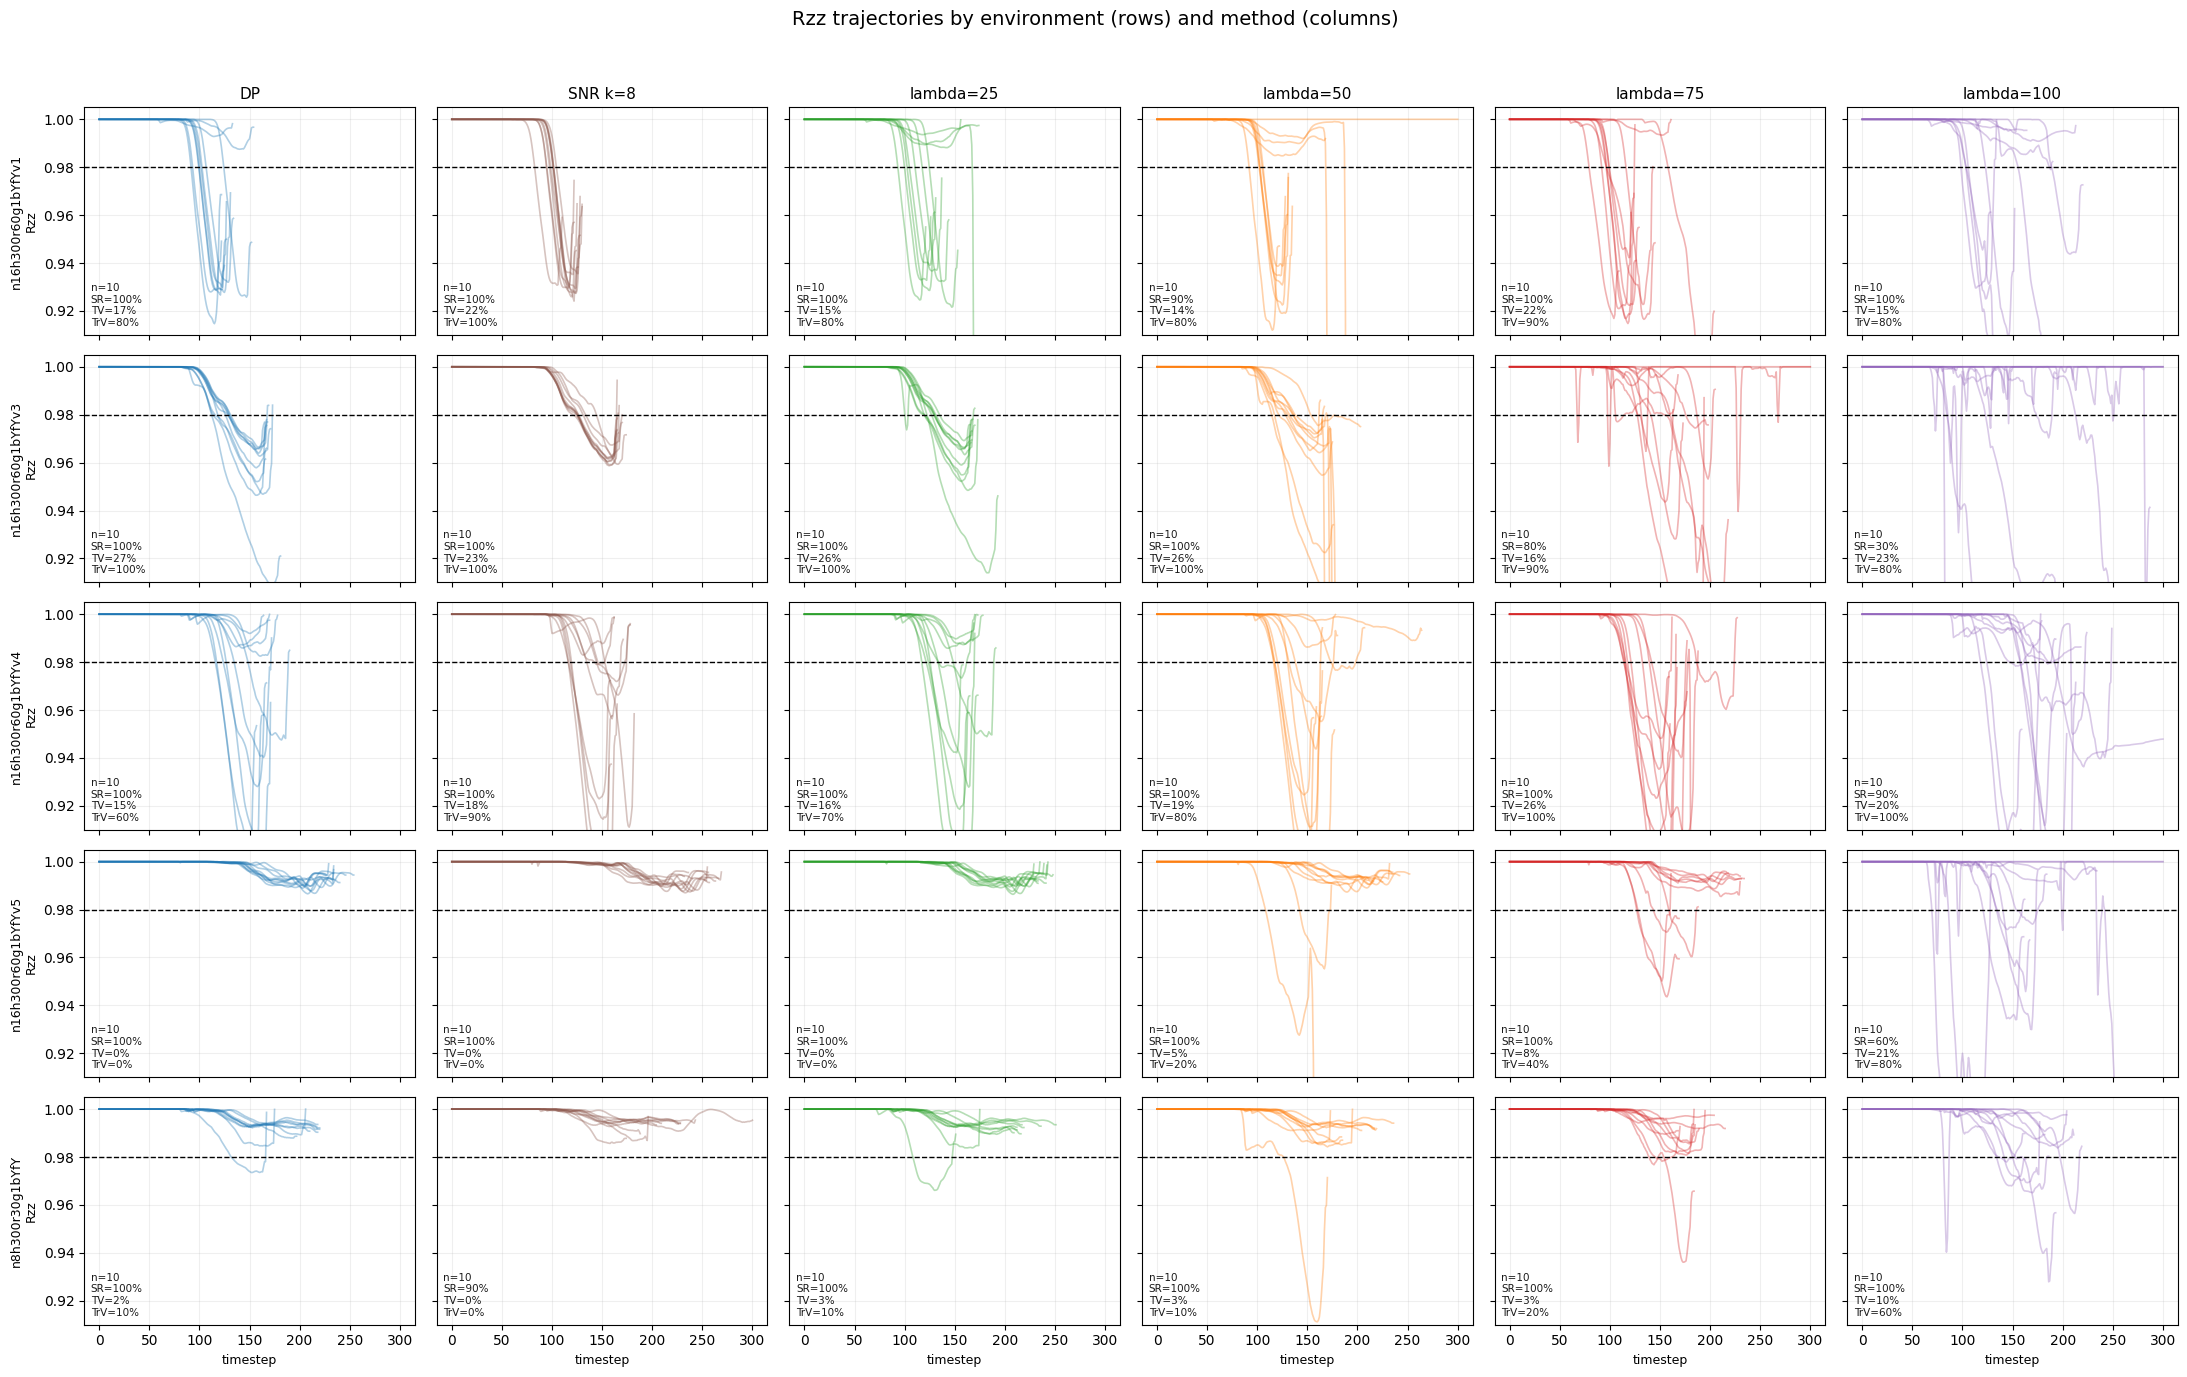

total plotted curves: 300
threshold: 0.98
shared y-limits: [0.91, 1.005]

Overall average metrics by method
Method         SR(%)   TV(%)  TrV(%)
----------------------------------
DP             100.0    12.3    50.0
SNR k=8         98.0    12.7    58.0
lambda=25      100.0    11.9    52.0
lambda=50       98.0    13.1    58.0
lambda=75       96.0    14.9    68.0
lambda=100      76.0    17.7    80.0


In [ ]:
# Comparing method effect: all 10 rollouts per method and environment

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# 5x6 grid: rows=envs, cols=methods
run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101")

envs = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]
methods = [
    "dp_base",
    "snr_k8",
    "dp_guidance_l25",
    "dp_guidance_l50",
    "dp_guidance_l75",
    "dp_guidance_l100",
]

method_labels = {
    "dp_base": "DP",
    "snr_k8": "SNR k=8",
    "dp_guidance_l25": "lambda=25",
    "dp_guidance_l50": "lambda=50",
    "dp_guidance_l75": "lambda=75",
    "dp_guidance_l100": "lambda=100",
}

method_colors = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "dp_guidance_l25": "#2ca02c",
    "dp_guidance_l50": "#ff7f0e",
    "dp_guidance_l75": "#d62728",
    "dp_guidance_l100": "#9467bd",
}

threshold = 0.98
ymin, ymax = 0.91, 1.005

fig, axes = plt.subplots(len(envs), len(methods), figsize=(22, 14), sharex=True, sharey=True)

total_plotted = 0
method_to_success_flags = {m: [] for m in methods}
method_to_timestep_violation_rates = {m: [] for m in methods}
method_to_trajectory_violation_flags = {m: [] for m in methods}

for i, env_name in enumerate(envs):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        rows_path = run_root / m / "rollout_rows.jsonl"
        with rows_path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]

        n_curves = 0
        success_flags = []
        timestep_violation_rates = []
        trajectory_violation_flags = []

        for r in rows:
            if r.get("init_name") != env_name:
                continue

            npz_path = run_root / m / f"{env_name}__seed_{int(r['seed']):02d}" / "rollout_numeric.npz"
            if not npz_path.exists():
                continue

            success_flag = float(bool(r.get("success", False)))
            success_flags.append(success_flag)
            method_to_success_flags[m].append(success_flag)

            rzz = np.load(npz_path)["rzz_mujoco"]
            below_threshold = rzz < threshold
            timestep_vr = float(np.mean(below_threshold) * 100.0)
            trajectory_vr = float(np.any(below_threshold) * 100.0)

            timestep_violation_rates.append(timestep_vr)
            trajectory_violation_flags.append(trajectory_vr)
            method_to_timestep_violation_rates[m].append(timestep_vr)
            method_to_trajectory_violation_flags[m].append(trajectory_vr)

            ax.plot(rzz, color=method_colors[m], alpha=0.35, lw=1.2)
            n_curves += 1
            total_plotted += 1

        sr = 100.0 * np.mean(success_flags) if success_flags else float("nan")
        timestep_vr = float(np.mean(timestep_violation_rates)) if timestep_violation_rates else float("nan")
        trajectory_vr = float(np.mean(trajectory_violation_flags)) if trajectory_violation_flags else float("nan")

        ax.axhline(threshold, color="black", linestyle="--", linewidth=1.0)
        ax.set_ylim(ymin, ymax)
        ax.grid(alpha=0.2)

        if i == 0:
            ax.set_title(method_labels[m], fontsize=11)
        if j == 0:
            ax.set_ylabel(f"{env_name}\nRzz", fontsize=9)
        if i == len(envs) - 1:
            ax.set_xlabel("timestep", fontsize=9)

        ax.text(
            0.02,
            0.04,
            f"n={n_curves}\nSR={sr:.0f}%\nTV={timestep_vr:.0f}%\nTrV={trajectory_vr:.0f}%",
            transform=ax.transAxes,
            fontsize=7.5,
            alpha=0.9,
        )

fig.suptitle("Rzz trajectories by environment (rows) and method (columns)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"total plotted curves: {total_plotted}")
print(f"threshold: {threshold}")
print(f"shared y-limits: [{ymin}, {ymax}]")
print()
print("Overall average metrics by method")
print(f"{'Method':<12} {'SR(%)':>7} {'TV(%)':>7} {'TrV(%)':>7}")
print("----------------------------------")
for m in methods:
    sr_vals = method_to_success_flags[m]
    tv_vals = method_to_timestep_violation_rates[m]
    trv_vals = method_to_trajectory_violation_flags[m]
    sr = 100.0 * np.mean(sr_vals) if sr_vals else float("nan")
    tv = float(np.mean(tv_vals)) if tv_vals else float("nan")
    trv = float(np.mean(trv_vals)) if trv_vals else float("nan")
    print(f"{method_labels[m]:<12} {sr:>7.1f} {tv:>7.1f} {trv:>7.1f}")

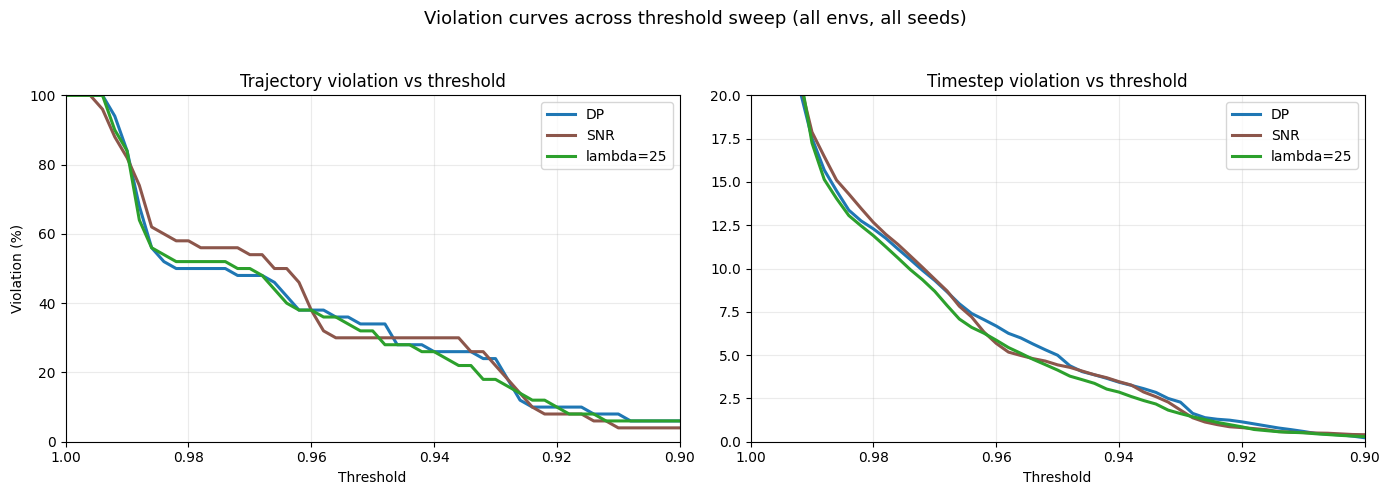

rollouts used per method:
- DP: 50
- SNR: 50
- lambda=25: 50
threshold range: 1.00 -> 0.90 (51 points)


In [ ]:
# Checking how much we can improve violation: threshold vs violation rates

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# Threshold-sweep violation curves
# Left: trajectory violation (% rollouts that ever go below threshold)
# Right: timestep violation (% timesteps below threshold, averaged over rollouts)
run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101")

envs = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]

# Compare exactly DP, SNR, and one lambda method.
METHODS = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "dp_guidance_l25": "lambda=25",
}

COLORS = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "dp_guidance_l25": "#2ca02c",
}

# User-requested sweep direction: start at 1.00 and decrease to 0.90.
thresholds = np.linspace(1.00, 0.90, 51)

method_to_rollouts = {m: [] for m in METHODS}
for m in METHODS:
    rows_path = run_root / m / "rollout_rows.jsonl"
    with rows_path.open("r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    for r in rows:
        if r.get("init_name") not in envs:
            continue

        npz_path = run_root / m / f"{r['init_name']}__seed_{int(r['seed']):02d}" / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        rzz = np.load(npz_path)["rzz_mujoco"]
        method_to_rollouts[m].append(np.asarray(rzz, dtype=np.float32))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
ax_traj, ax_time = axes

for m, label in METHODS.items():
    rollouts = method_to_rollouts[m]
    if not rollouts:
        continue

    traj_curve = []
    time_curve = []

    for thr in thresholds:
        per_rollout_timestep = [100.0 * float(np.mean(rzz < thr)) for rzz in rollouts]
        per_rollout_trajectory = [100.0 * float(np.any(rzz < thr)) for rzz in rollouts]

        time_curve.append(float(np.mean(per_rollout_timestep)))
        traj_curve.append(float(np.mean(per_rollout_trajectory)))

    ax_traj.plot(thresholds, traj_curve, lw=2.2, color=COLORS[m], label=label)
    ax_time.plot(thresholds, time_curve, lw=2.2, color=COLORS[m], label=label)

ax_traj.set_title("Trajectory violation vs threshold")
ax_traj.set_ylabel("Violation (%)")
ax_traj.set_xlabel("Threshold")
ax_traj.grid(alpha=0.25)

ax_time.set_title("Timestep violation vs threshold")
ax_time.set_xlabel("Threshold")
ax_time.grid(alpha=0.25)

ax_traj.set_ylim(0, 100)
ax_time.set_ylim(0, 20)
ax_traj.legend(frameon=True)
ax_time.legend(frameon=True)

# Keep x-axis descending so the left side is 1.00 and right side is 0.90.
ax_traj.set_xlim(1.00, 0.90)
ax_time.set_xlim(1.00, 0.90)

fig.suptitle("Violation curves across threshold sweep (all envs, all seeds)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("rollouts used per method:")
for m, label in METHODS.items():
    print(f"- {label}: {len(method_to_rollouts[m])}")
print(f"threshold range: {thresholds[0]:.2f} -> {thresholds[-1]:.2f} ({len(thresholds)} points)")

### One inital state (v1), ran over 50 seeds

In [ ]:
# Sanity check: plot DP rollouts for the V1 init state, seeds 1-10.
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101")
method_slug = "dp_base"
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 11)
threshold = 0.98
ymin, ymax = 0.91, 1.005

rows_path = run_root / method_slug / "rollout_rows.jsonl"
with rows_path.open("r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

seed_to_rzz = {}
for r in rows:
    if r.get("init_name") != env_name:
        continue

    seed = int(r["seed"])
    if seed not in seed_range:
        continue

    npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
    if npz_path.exists():
        seed_to_rzz[seed] = np.load(npz_path)["rzz_mujoco"]

fig, ax = plt.subplots(figsize=(12, 4.5))
cmap = plt.get_cmap("tab10")

for idx, seed in enumerate(seed_range):
    rzz = seed_to_rzz.get(seed)
    if rzz is None:
        continue

    ax.plot(rzz, color=cmap(idx % 10), lw=1.8, alpha=0.9, label=f"seed {seed}")

ax.axhline(threshold, color="black", linestyle="--", linewidth=1.0)
ax.set_title("DP rollouts for V1 init state, seeds 1-10")
ax.set_xlabel("timestep")
ax.set_ylabel("Rzz")
ax.set_ylim(ymin, ymax)
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

print(f"plotted seeds: {sorted(seed_to_rzz)}")
missing = [seed for seed in seed_range if seed not in seed_to_rzz]
print(f"missing seeds: {missing}")